# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

#### Notas acerca del método `extract_custom_embedding()`

Para la sección de Etapa 2 los docentes informaron que `extract_custom_embedding()` no era requerida por la consigna. En nuestro caso la dejamos implementada como extensión del sistema, ya que nos permitio usar el Modelo B como extractor de embeddings compatibles con la infraestructura de pgvector (EMBEDDING_DIM=512). 

## Equipo
- Alumno 1 : Almada Manuela
- Alumno 2 : Sanz Alfredo

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [ ]:
from getpass import getpass

# Token de GitHub (Settings -> Developer settings -> Personal access tokens).
# Usamos getpass para que el token NO quede guardado en este notebook .
TOKEN = getpass("GitHub token: ")
REPO_URL = f"https://{TOKEN}@github.com/manuela-almada/tuia-dog-recognition-app.git"

!git clone -b _aves $REPO_URL proyecto
%cd proyecto

GitHub token: ··········
Cloning into 'proyecto'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 189 (delta 32), reused 61 (delta 25), pack-reused 114 (from 1)
Receiving objects: 100% (189/189), 8.66 MiB | 9.10 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/content/proyecto


In [ ]:
!git branch --show-current
!ls src/lib/services/

_aves
classifier_service.py  __init__.py	      task_manager.py
detection_service.py   similarity_service.py


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [ ]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 62.3 MB/s eta 0:00:00


## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [ ]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: True


In [ ]:
# Verificamos dependencias
from lib.bootstrap import build_classifier
print("bootstrap OK")

bootstrap OK


## 4. Descargar el dataset

In [ ]:
from google.colab import files
print("Subí tu kaggle.json (lo tenés en ~/.kaggle/ de tu máquina):")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print("Kaggle configurado ✅")

Subí tu kaggle.json (lo tenés en ~/.kaggle/ de tu máquina):


Saving kaggle.json to kaggle.json
Kaggle configurado ✅


In [ ]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/data/dataset
dogs.csv  test	train  valid


### Normalización de nombres de carpetas (limpieza previa)

El dataset trae alguna inconsistencia en los nombres de carpeta (p. ej. `American  Spaniel`
con doble espacio en alguna partición). Como el sistema deriva las **clases** del nombre de
cada carpeta y de su orden alfabético, normalizamos los nombres **en disco, antes de
cualquier análisis o entrenamiento**, para que `train`, `valid` y `test` usen exactamente
los mismos nombres y no haya desalineación de clases entre particiones.

La celda es **idempotente**: si los nombres ya están limpios, no hace nada. Opera solo
sobre la copia descargada en Colab (no toca el repositorio).


In [ ]:
from pathlib import Path
import shutil

dataset_path = Path(settings.dataset_path)
splits = ["train", "valid", "test"]

def norm(name):
    return " ".join(name.split())   # colapsa espacios dobles y recorta extremos

renombrados = fusionados = 0
for split in splits:
    split_dir = dataset_path / split
    if not split_dir.exists():
        print(f"[aviso] no existe {split_dir}")
        continue
    for d in list(split_dir.iterdir()):
        if not d.is_dir():
            continue
        nuevo = norm(d.name)
        if nuevo == d.name:
            continue
        destino = split_dir / nuevo
        if destino.exists():
            # la versión limpia ya existe -> movemos los archivos y borramos la carpeta vieja
            for f in d.iterdir():
                shutil.move(str(f), str(destino / f.name))
            d.rmdir()
            fusionados += 1
            print(f"[fusión]     {split}/{d.name!r} -> {nuevo!r}")
        else:
            d.rename(destino)
            renombrados += 1
            print(f"[renombrado] {split}/{d.name!r} -> {nuevo!r}")

print(f"\nListo. Renombrados: {renombrados} | Fusionados: {fusionados}")
if renombrados == fusionados == 0:
    print("Los nombres ya estaban limpios.")


[renombrado] valid/'American  Spaniel' -> 'American Spaniel'

Listo. Renombrados: 1 | Fusionados: 0


## 5. Análisis del dataset

Trabajamos con el **70 Dog Breeds Image Dataset**, que viene organizado en tres
particiones (`train`, `valid`, `test`), cada una con una carpeta por raza.

En esta sección:
- Contamos las imágenes por raza y por partición.
- Analizamos la distribución de clases (balance / desbalance).
- Mostramos ejemplos del dataset.

El **conjunto independiente de evaluación** (imágenes descargadas de internet) se
arma y se evalúa más abajo, una vez entrenados los modelos.


In [ ]:
from pathlib import Path
import pandas as pd

dataset_path = Path(settings.dataset_path)
splits = ["train", "valid", "test"]
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def norm(name):
    # El dataset tiene alguna carpeta con doble espacio (p.ej. "American  Spaniel");
    # colapsamos espacios para no contar la misma raza dos veces.
    return " ".join(name.split())

# Conteo de imagenes por raza y por particion
counts = {}
for split in splits:
    split_dir = dataset_path / split
    if not split_dir.exists():
        print(f"[aviso] no existe {split_dir}")
        continue
    for breed_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        n = sum(1 for f in breed_dir.iterdir() if f.suffix.lower() in IMG_EXT)
        d = counts.setdefault(norm(breed_dir.name), {})
        d[split] = d.get(split, 0) + n

df = pd.DataFrame(counts).T.fillna(0).astype(int)
df = df[[s for s in splits if s in df.columns]]
df["total"] = df.sum(axis=1)
df = df.sort_index()

print(f"Cantidad de razas (clases): {len(df)}")
print("Totales por partición:")
print(df[[s for s in splits if s in df.columns]].sum())
print(f"\nTotal de imágenes: {int(df['total'].sum())}")
df.head(10)


Cantidad de razas (clases): 70
Totales por partición:
train    7946
valid     700
test      700
dtype: int64

Total de imágenes: 9346


,train,valid,test,total
Afghan,105,10,10,125
African Wild Dog,109,10,10,129
Airedale,117,10,10,137
American Hairless,65,10,10,85
American Spaniel,89,10,10,109
Basenji,99,10,10,119
Basset,159,10,10,179
Beagle,123,10,10,143
Bearded Collie,79,10,10,99
Bermaise,131,10,10,151


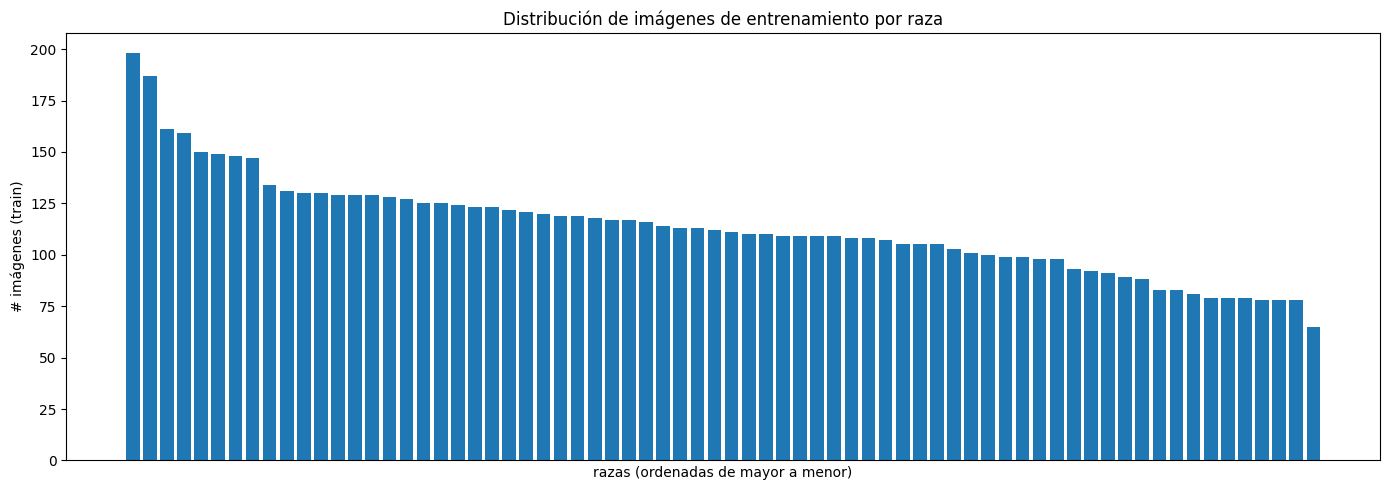

Estadísticas de imágenes de train por raza:
count     70.0
mean     113.5
std       24.7
min       65.0
25%       99.0
50%      111.5
75%      125.0
max      198.0
Name: train, dtype: float64

Raza con más train: 198 | con menos: 65 | ratio máx/mín: 3.05
valid y test suelen estar balanceados (misma cantidad por raza):
  valid por raza -> [np.int64(10)]
  test  por raza -> [np.int64(10)]


In [ ]:
import matplotlib.pyplot as plt

# Distribucion de imagenes de entrenamiento por raza
df_sorted = df.sort_values("train", ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(df_sorted)), df_sorted["train"])
ax.set_title("Distribución de imágenes de entrenamiento por raza")
ax.set_xlabel("razas (ordenadas de mayor a menor)")
ax.set_ylabel("# imágenes (train)")
ax.set_xticks([])
plt.tight_layout(); plt.show()

print("Estadísticas de imágenes de train por raza:")
print(df["train"].describe().round(1))
ratio = df["train"].max() / max(df["train"].min(), 1)
print(f"\nRaza con más train: {df['train'].max()} | con menos: {df['train'].min()} | ratio máx/mín: {ratio:.2f}")
print("valid y test suelen estar balanceados (misma cantidad por raza):")
print("  valid por raza ->", sorted(df["valid"].unique()) if "valid" in df else "n/a")
print("  test  por raza ->", sorted(df["test"].unique()) if "test" in df else "n/a")


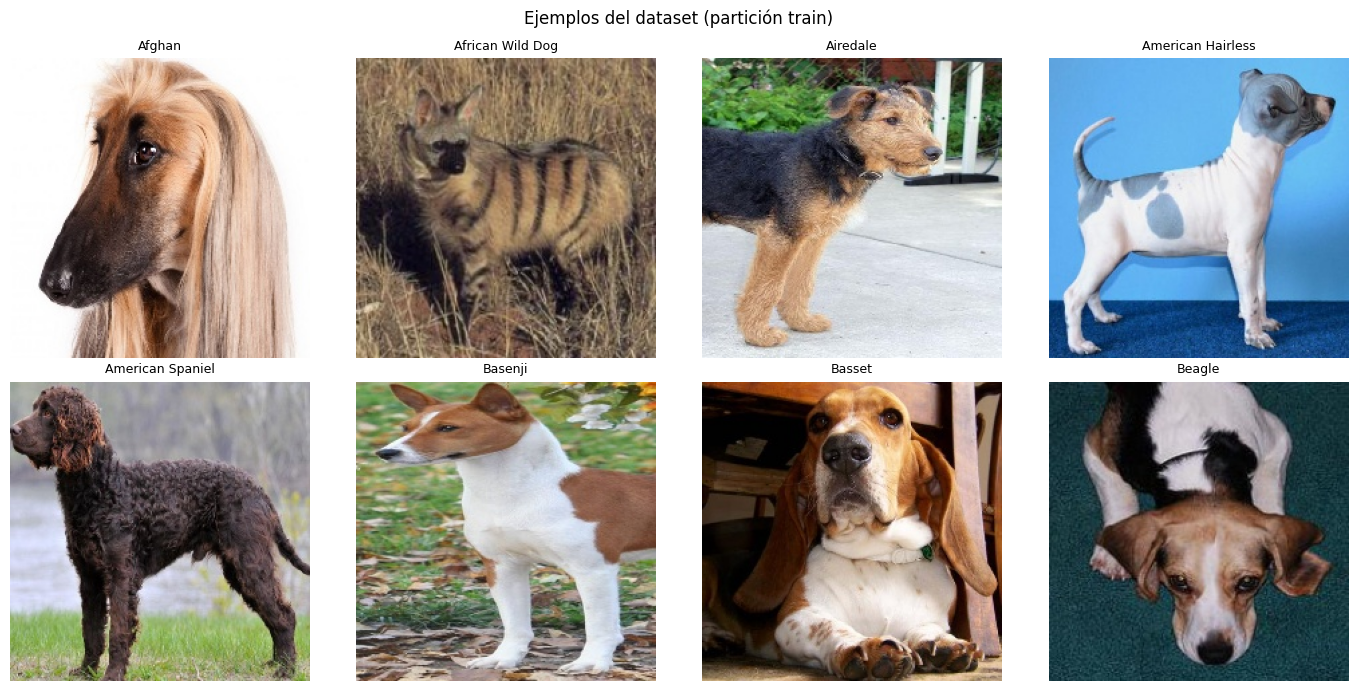

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path(settings.dataset_path)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
train_dir = dataset_path / "train"

# Tomamos las razas directamente de la carpeta train (siempre existen ahí)
sample_breeds = sorted(p.name for p in train_dir.iterdir() if p.is_dir())[:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, breed in zip(axes.ravel(), sample_breeds):
    bdir = train_dir / breed
    img_path = next((p for p in bdir.iterdir() if p.suffix.lower() in IMG_EXT), None)
    ax.axis("off")
    if img_path is None:
        continue
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(breed, fontsize=9)
plt.suptitle("Ejemplos del dataset (partición train)")
plt.tight_layout(); plt.show()


## 6. Preprocesamiento

Todas las imágenes pasan por un preprocesamiento común y, sólo en entrenamiento, por
data augmentation. El pipeline está implementado en `classifier_service.py`
(`_build_train_transform` / `_build_eval_transform`); acá visualizamos **exactamente
ese mismo pipeline**, para no introducir diferencias entre lo que se grafica y lo que
realmente entrena.

**Común a train / valid / test (determinístico):**
- **Resize 224×224**: tamaño de entrada fijo que esperan ResNet18 y la CNN propia.
- **Normalización ImageNet** (media y desvío de ImageNet): requerida por los pesos
  pre-entrenados de la ResNet, y usada también en la Etapa 1 → consistencia.

**Sólo en entrenamiento (data augmentation, para regularizar):**
- **Horizontal Flip** (p=0.5): un perro reflejado sigue siendo válido. No usamos flip
  *vertical* porque un perro "patas arriba" no es realista.
- **Rotación ±15°** (p=0.5): robustez a pequeñas variaciones de pose/encuadre.
- **Brillo y contraste ±20%** (p=0.5): robustez a condiciones de iluminación.
- **Blur (gaussiano o de movimiento)** (p=0.3): simula fotos fuera de foco o con movimiento.
- **Ruido gaussiano** (p=0.3): simula ruido de sensor / baja calidad.

Validación y test usan **sólo** resize + normalización (sin augmentation), para evaluar
de forma determinística y evitar *train/serve skew*.

**Filtrado de baja calidad:** el dataset provisto está curado; además, el cargador
(`AlbumentationsImageFolder`) corta con error ante archivos ilegibles o corruptos, de
modo que no se cuelan imágenes inválidas en el entrenamiento.


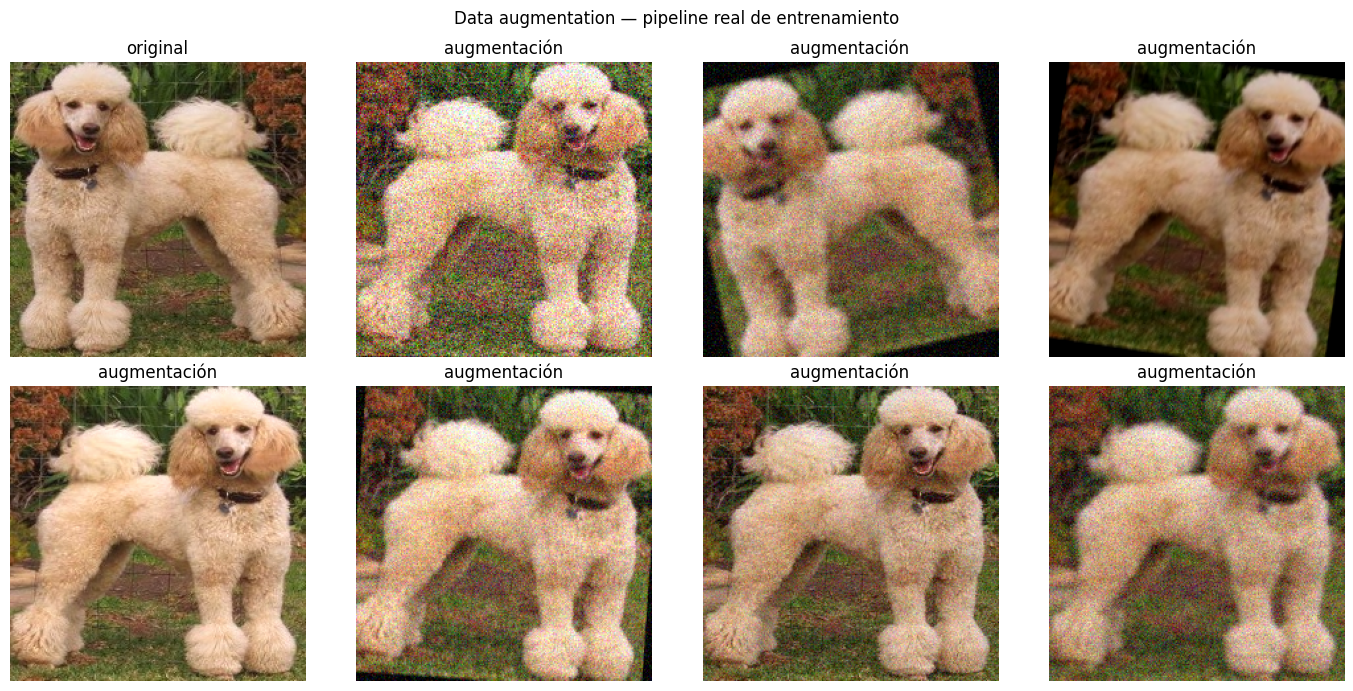

In [ ]:
from lib.bootstrap import build_classifier
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Construimos el servicio (sólo configuración, no entrena) para usar SU pipeline real
classifier = build_classifier(settings)
train_tf = classifier._build_train_transform()   # mismo transform que usa el entrenamiento

# Imagen de muestra
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
sample = next(p for p in (Path(settings.dataset_path) / "train").rglob("*") if p.suffix.lower() in IMG_EXT)
img_rgb = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)

# Para visualizar hay que deshacer la normalización ImageNet
MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])
def to_img(t):
    arr = t.permute(1, 2, 0).numpy() * STD + MEAN
    return np.clip(arr, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(img_rgb); axes[0, 0].set_title("original"); axes[0, 0].axis("off")
for ax in axes.ravel()[1:]:
    aug = train_tf(image=img_rgb)["image"]      # tensor CHW normalizado
    ax.imshow(to_img(aug)); ax.set_title("augmentación"); ax.axis("off")
plt.suptitle("Data augmentation — pipeline real de entrenamiento")
plt.tight_layout(); plt.show()


## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

Tiempo de Ejecución estimado para esta celda: 10 minuntos (Entorno GPU)

In [ ]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


{'train_loss': [2.191367018711888,
  1.03704117525443,
  0.6393319745073384,
  0.37662023070354833,
  0.26602819160643376,
  0.20501569639624156,
  0.16542708832492103,
  0.12326792445856109,
  0.09982223157284993,
  0.09095045790524453,
  0.06351818613053538,
  0.05454394094066508,
  0.046682868994399246,
  0.040896595845534824,
  0.03373319048621089,
  0.031045805427519824,
  0.027519010936125472,
  0.023771927822095276,
  0.0201019265794676,
  0.021115060543593158],
 'train_acc': [0.5168638308582935,
  0.7479234835137176,
  0.8102189781021898,
  0.8847218726403222,
  0.9181978353888749,
  0.9372011074754594,
  0.9504153032972564,
  0.9660206393153788,
  0.9731940599043544,
  0.9762144475207651,
  0.9837654165617921,
  0.9856531588220488,
  0.9884218474704254,
  0.9896803423105965,
  0.9932041278630758,
  0.9924490309589731,
  0.9940850742511955,
  0.9952177196073496,
  0.9962245154794865,
  0.9973571608356405],
 'val_loss': [0.5742362354482923,
  0.3492376583814621,
  0.220835378340

In [ ]:
!ls -lh models/

total 43M
-rw-r--r-- 1 root root 43M Jun 20 17:54 resnet18_finetuned.pth


In [ ]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.96,
 'precision': 0.9627499484642342,
 'recall': 0.9600000000000001,
 'specificity': 0.9994202898550725,
 'f1': 0.9597628844201158}

In [ ]:
# Guardamos el historial de entrenamiento de la ResNet (Modelo A) para la comparacion
# de curvas mas abajo. classifier.history se pisa cuando se entrena la CNN (Modelo B).
history_a = classifier.history

### Curvas de entrenamiento y matriz de confusion (Modelo A)


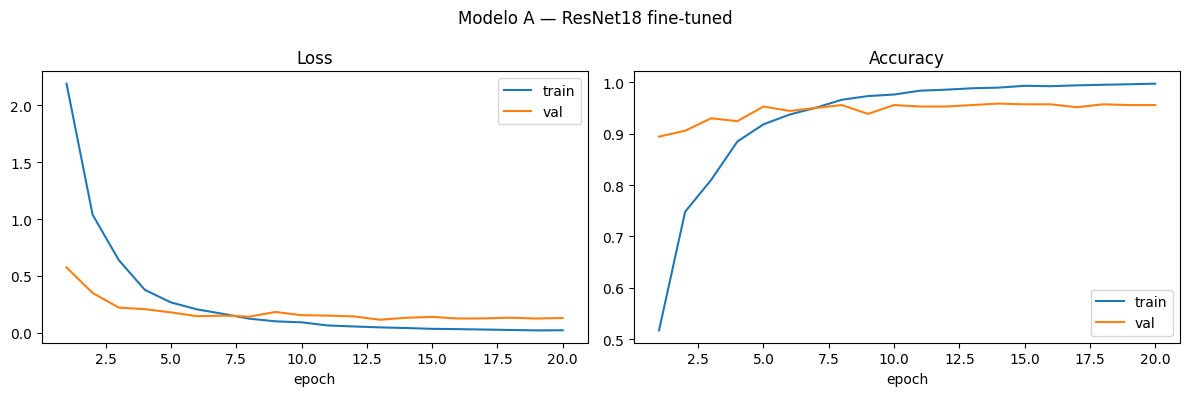

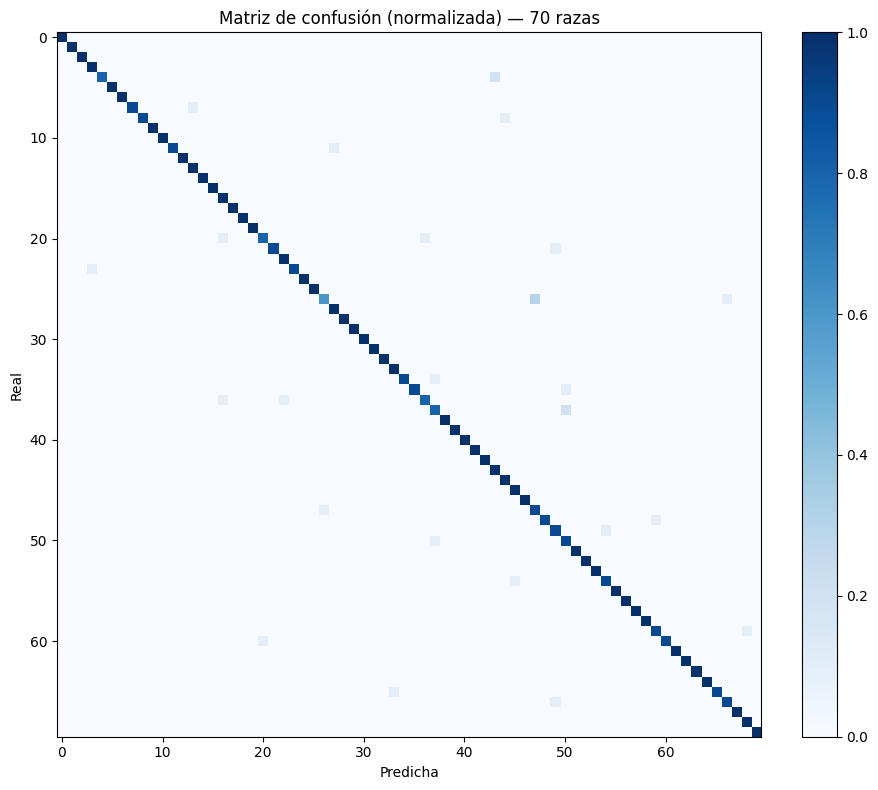

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

h = classifier.history
ev = classifier.last_eval

# --- Curvas de entrenamiento ---
epochs = range(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, h["train_loss"], label="train"); ax[0].plot(epochs, h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["train_acc"], label="train"); ax[1].plot(epochs, h["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Modelo A — ResNet18 fine-tuned"); plt.tight_layout(); plt.show()

# --- Matriz de confusion (normalizada por clase real) ---
cm = ev["cm"].astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_title(f"Matriz de confusión (normalizada) — {len(ev['classes'])} razas")
ax.set_xlabel("Predicha"); ax.set_ylabel("Real")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

## Análisis de resultados del modelo ResNet18 con fine-tuning

Las métricas obtenidas reflejan un desempeño altamente satisfactorio del modelo ResNet18 luego del proceso de *fine-tuning*. Tanto el **Accuracy** como el **Precision**, **Recall** y **F1-score** superan el 90%, lo que indica una excelente capacidad del modelo para clasificar correctamente las distintas razas de perros.

Estos resultados evidencian que el *fine-tuning* constituye una estrategia muy adecuada para esta tarea. Aprovechar un modelo previamente entrenado sobre ImageNet permite reutilizar características generales aprendidas durante el entrenamiento original, como la detección de bordes, líneas, texturas y formas básicas. Posteriormente, el ajuste fino adapta esas representaciones al problema específico de clasificación de razas de perros. Este enfoque resulta especialmente conveniente cuando, como en este trabajo, no se dispone de millones de imágenes para entrenar un modelo desde cero.

En cuanto a las curvas de entrenamiento, puede observarse que, poco antes de la época 10, la pérdida del conjunto de validación comienza a incrementarse mientras que la pérdida del conjunto de entrenamiento continúa disminuyendo. Este comportamiento constituye un indicio temprano de sobreajuste (*overfitting*). Sin embargo, la diferencia entre ambas curvas se mantiene relativamente reducida, aproximadamente entre 0.2 y 0.3, por lo que el fenómeno no parece ser severo ni comprometer significativamente la capacidad de generalización del modelo.

Un comportamiento similar puede apreciarse en las curvas de *accuracy*: mientras el desempeño sobre el conjunto de entrenamiento continúa mejorando, el correspondiente al conjunto de validación presenta una leve disminución. No obstante, dado que el dataset presenta un cierto grado de desbalance entre clases, el *accuracy* por sí solo no resulta la métrica más representativa del desempeño global. En este contexto, métricas como el **F1-score**, que consideran simultáneamente la precisión y el *recall*, ofrecen una evaluación más robusta. En este caso, el elevado valor obtenido para el F1-score confirma que el modelo mantiene un excelente equilibrio entre ambas medidas.

Finalmente, la matriz de confusión normalizada muestra que el modelo distingue correctamente la gran mayoría de las razas, sin evidenciar confusiones sistemáticas o de gran magnitud entre clases. Si bien existen algunas razas que presentan mayores dificultades de clasificación, probablemente debido a similitudes morfológicas que incluso pueden resultar complejas para un observador humano, la diagonal principal concentra la mayor parte de las predicciones, lo que indica que, en términos generales, las clases reales y las predichas coinciden en la mayoría de los casos.

Debido a la gran cantidad de razas presentes en el dataset, la matriz de confusión resulta visualmente muy densa, lo que dificulta analizar errores asociados a clases específicas. Sin embargo, su estructura general permite concluir que el modelo presenta un comportamiento consistente y una elevada capacidad de discriminación entre las distintas categorías.


## 8. Modelo B: CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

La CNN propia tiene cinco bloques.

Cada bloque hace dos cosas: primero mira la imagen con filtros (convolución: detecta patrones), después la achica a la mitad (pooling: se queda con lo importante).

A medida que avanzamos, la imagen se hace más chica pero la describimos con más canales (más tipos de patrones detectados a la vez):

*   Bloque 1: 224→112 píxeles, 3→32 canales — detecta bordes y colores simples.
*   Bloque 2: 112→56 píxeles, 32→64 canales — texturas (pelo, manchas).
*   Bloque 3: 56→28 píxeles, 64→128 canales — partes (orejas, hocico).
*   Bloque 4: 28→14 píxeles, 128→256 canales — combinaciones de partes.
*   Bloque 5: 14→7 píxeles, 256→512 canales — formas más completas, propias de cada raza.

Tiempo de Ejecución estimado para esta celda: 15 minuntos (Entorno GPU)

In [ ]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

{'accuracy': 0.7028571428571428,
 'precision': 0.7166248095974986,
 'recall': 0.702857142857143,
 'specificity': 0.9956935817805384,
 'f1': 0.6923722833284204}

In [ ]:
eval_b = classifier.last_eval   # matriz de confusión del Modelo B (CNN), antes de que se pise

In [ ]:
history_b = classifier.history   # curvas de la CNN (Modelo B), antes de que se pisen

In [ ]:
classifier.set_active_model("resnet18_finetuned")
metrics_a = classifier.evaluate_classifier()   # carga la ResNet ya entrenada y la evalúa (sin reentrenar)
eval_a = classifier.last_eval                  # matriz de confusión del Modelo A (ResNet)
metrics_a

{'accuracy': 0.96,
 'precision': 0.9627499484642342,
 'recall': 0.9600000000000001,
 'specificity': 0.9994202898550725,
 'f1': 0.9597628844201158}

## 9. Estudio comparativo

- Comparación de los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analisis de las clases con peor desempeño (falsos positivos / falsos negativos).
- Trade-offs: performance vs costo computacional.


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "ResNet18 (fine-tuned)": metrics_a,
    "CNN propia": metrics_b,
})
comparison["diferencia (A - B)"] = comparison["ResNet18 (fine-tuned)"] - comparison["CNN propia"]
comparison.index.name = "métrica"
comparison.round(4)

,ResNet18 (fine-tuned),CNN propia,diferencia (A - B)
métrica,,,
accuracy,0.9600,0.7029,0.2571
precision,0.9627,0.7166,0.2461
recall,0.9600,0.7029,0.2571
specificity,0.9994,0.9957,0.0037
f1,0.9598,0.6924,0.2674


### Curvas de entrenamiento (comparación A vs B)


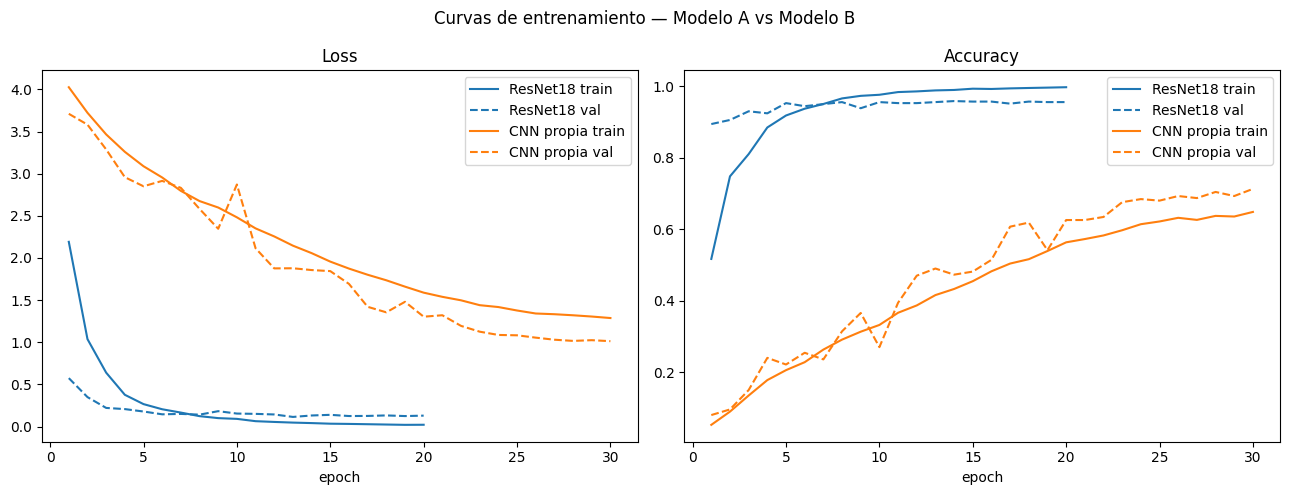

In [ ]:
import matplotlib.pyplot as plt

# ResNet (20 epochs) y CNN (30 epochs) tienen distinta cantidad de epocas:
# cada una se grafica con su propio rango. Color = modelo, linea continua = train,
# linea punteada = validacion.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for hist, name, color in [(history_a, "ResNet18", "tab:blue"),
                          (history_b, "CNN propia", "tab:orange")]:
    ep = range(1, len(hist["train_loss"]) + 1)
    ax[0].plot(ep, hist["train_loss"], color=color, linestyle="-",  label=f"{name} train")
    ax[0].plot(ep, hist["val_loss"],   color=color, linestyle="--", label=f"{name} val")
    ax[1].plot(ep, hist["train_acc"],  color=color, linestyle="-",  label=f"{name} train")
    ax[1].plot(ep, hist["val_acc"],    color=color, linestyle="--", label=f"{name} val")

ax[0].set_title("Loss");     ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("Curvas de entrenamiento — Modelo A vs Modelo B")
plt.tight_layout(); plt.show()

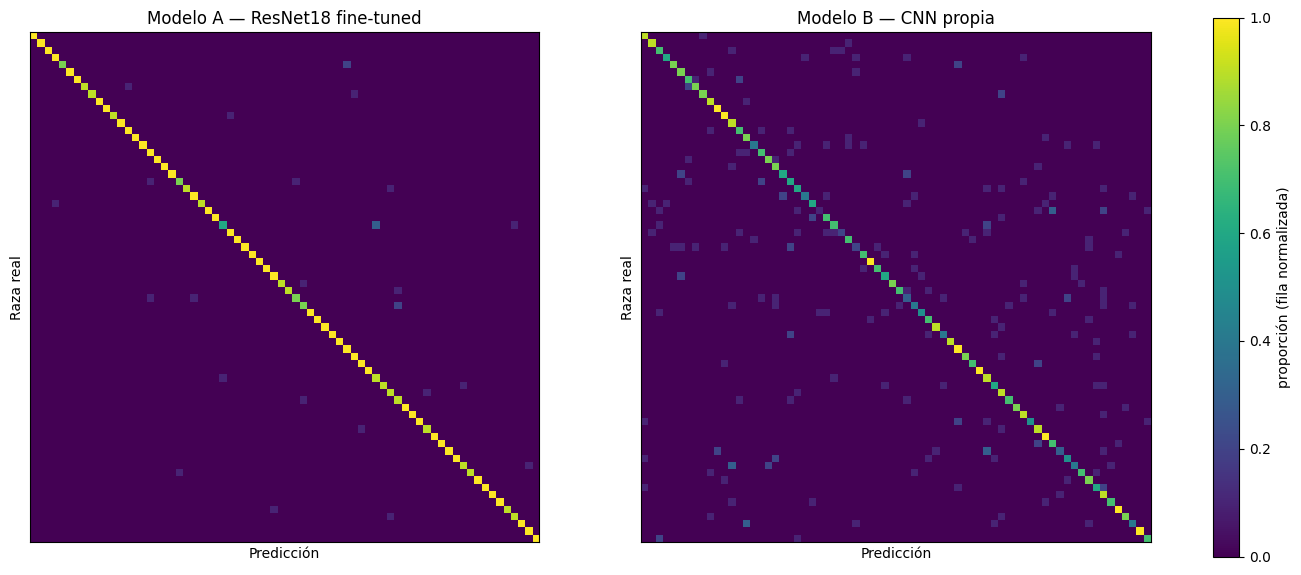

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion(eval_data, title, ax):
    cm = eval_data["cm"].astype(float)
    # Normalizamos por fila (cada fila es una raza real) -> proporciones 0..1, color comparable
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Raza real")
    ax.set_xticks([]); ax.set_yticks([])   # 70 etiquetas no entran legibles
    return im

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_confusion(eval_a, "Modelo A — ResNet18 fine-tuned", axes[0])
im = plot_confusion(eval_b, "Modelo B — CNN propia", axes[1])
fig.colorbar(im, ax=axes, fraction=0.046, label="proporción (fila normalizada)")
plt.show()

## Análisis de la CNN propuesta

Las métricas obtenidas por la CNN diseñada para este trabajo muestran un desempeño considerablemente inferior al alcanzado por el modelo ResNet18 con *fine-tuning*. En la mayoría de las métricas el modelo no supera el 72%, obteniendo aproximadamente un **70% de Accuracy** y un **69% de F1-score**. Estos resultados evidencian que, si bien la red es capaz de aprender características relevantes del conjunto de datos, su capacidad de generalización resulta significativamente menor que la del modelo preentrenado.

La principal diferencia radica en el punto de partida de ambos enfoques. Mientras que ResNet18 comienza el entrenamiento con millones de parámetros previamente ajustados sobre ImageNet y posteriormente adapta ese conocimiento a la tarea específica mediante *transfer learning*, la CNN propuesta debe aprender todas las representaciones visuales desde cero utilizando únicamente las imágenes disponibles en nuestro dataset. Aunque la arquitectura fue diseñada siguiendo una estructura jerárquica típica de redes convolucionales, aprendiendo progresivamente bordes, texturas, partes del objeto y finalmente características de alto nivel propias de cada raza, la cantidad de datos disponible no resulta suficiente para alcanzar representaciones tan discriminativas como las obtenidas por un modelo preentrenado.

En cuanto a las curvas de entrenamiento, se observa un comportamiento diferente al de ResNet18. La pérdida sobre el conjunto de validación resulta incluso inferior a la pérdida de entrenamiento durante gran parte del proceso. Del mismo modo, el *accuracy* de validación se mantiene ligeramente por encima del correspondiente al entrenamiento. Este comportamiento puede atribuirse a distintos factores, entre ellos la utilización de técnicas de regularización y aumento de datos (*data augmentation*) durante el entrenamiento, que incrementan la dificultad de las muestras vistas por el modelo. En consecuencia, las imágenes del conjunto de validación pueden resultar relativamente más sencillas de clasificar, generando esta diferencia entre ambas curvas.

Finalmente, la matriz de confusión refleja con claridad las limitaciones del modelo. A diferencia de lo observado en ResNet18, la diagonal principal aparece menos definida, indicando que las predicciones correctas se distribuyen con menor concentración y que las confusiones entre distintas razas son considerablemente más frecuentes. Esto evidencia una menor capacidad del modelo para aprender características discriminativas que permitan diferenciar razas visualmente similares. En términos generales, la CNN logra capturar patrones relevantes del problema, pero no alcanza el nivel de especialización y capacidad de generalización proporcionado por el enfoque basado en *transfer learning*.


In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

def top_confusions(eval_data, n=10):
    """Pares (raza real -> predicho) que más se confunden, ignorando la diagonal (aciertos)."""
    cm = eval_data["cm"].copy()
    classes = eval_data["classes"]
    np.fill_diagonal(cm, 0)                      # sacamos los aciertos, solo miramos confusiones
    order = np.argsort(cm, axis=None)[::-1]      # celdas de mayor a menor
    rows = []
    for idx in order[:n]:
        i, j = np.unravel_index(idx, cm.shape)
        if cm[i, j] == 0:
            break
        rows.append({"raza real": classes[i], "predicho como": classes[j], "veces": int(cm[i, j])})
    return pd.DataFrame(rows)

print("Modelo B — CNN propia: pares más confundidos")
display(top_confusions(eval_b, n=10))
print("\nModelo A — ResNet18 fine-tuned: pares más confundidos")
display(top_confusions(eval_a, n=10))

Modelo B — CNN propia: pares más confundidos


,raza real,predicho como,veces
0,Chow,Pomeranian,3
1,Siberian Husky,Border Collie,3
2,Poodle,Labradoodle,3
3,Rhodesian,Bloodhound,3
4,French Bulldog,Pug,2
5,Bull Terrier,Basenji,2
6,Cockapoo,Labradoodle,2
7,Basset,Bluetick,2
8,American Spaniel,Irish Spaniel,2
9,Pug,Bull Mastiff,2



Modelo A — ResNet18 fine-tuned: pares más confundidos


,raza real,predicho como,veces
0,Cockapoo,Labradoodle,3
1,German Sheperd,Malinois,2
2,American Spaniel,Irish Spaniel,2
3,Lhasa,Pekinese,1
4,Blenheim,Cocker,1
5,Malinois,German Sheperd,1
6,Bulldog,Boston Terrier,1
7,Labradoodle,Cockapoo,1
8,Beagle,Bluetick,1
9,Elk Hound,Malinois,1


Como se observó anteriormente en las matrices de confusión, tanto el modelo ResNet18 con fine-tuning como la CNN diseñada desde cero presentan dificultades para distinguir algunas parejas de razas. A continuación se muestran los pares que generan la mayor cantidad de confusiones. En particular, las razas más confundidas por cada modelo fueron:

- Pomeranian – Chow (CNN propia).

- Cockapoo – Labradoodle (ResNet18 con fine-tuning).

Al analizar visualmente estas razas, se aprecia que comparten numerosas características morfológicas. En ambos casos presentan similitudes en el color y la textura del pelaje, además de una estructura facial y una forma de la cabeza muy parecidas. Estas semejanzas reducen la capacidad discriminativa de las características aprendidas por los modelos, especialmente cuando las imágenes presentan variaciones de iluminación, pose o perspectiva.

Por este motivo, resulta esperable que estas razas concentren una mayor proporción de errores de clasificación. Aun así, la cantidad de confusiones es significativamente menor en ResNet18 que en la CNN propia, lo que evidencia la superior capacidad del modelo preentrenado para aprender representaciones visuales más robustas y discriminativas.

## Evaluación independiente (imágenes de internet)

Para medir la **generalización** más allá del dataset de Kaggle, evaluamos los dos
modelos sobre un conjunto propio de imágenes descargadas de internet.

**Cómo se preparó (una sola vez, ya hecho):**
- ~5 imágenes por raza, para un puñado de razas que están entre las 70 del dataset.
- Organizadas en `eval_externa/<NombreRaza>/...`, usando el **nombre exacto** de cada
  raza (la celda siguiente imprime la lista; el dataset tiene grafías
  particulares, p. ej. `Dalmation`).

**Dónde vive la carpeta:** `eval_externa/` está versionada en el repositorio, en la
**raíz del proyecto** (no dentro de `data/`, que está en `.gitignore`). Al clonar en
Colab queda en `/content/proyecto/eval_externa/`, y las celdas la leen directo.


In [ ]:
# Nombres de raza válidos (deben coincidir con los nombres de carpeta en eval_externa/)
modelo = classifier.load_model()
print(f"{len(modelo.classes)} razas válidas:\n")
print(", ".join(modelo.classes))


70 razas válidas:

Afghan, African Wild Dog, Airedale, American Hairless, American Spaniel, Basenji, Basset, Beagle, Bearded Collie, Bermaise, Bichon Frise, Blenheim, Bloodhound, Bluetick, Border Collie, Borzoi, Boston Terrier, Boxer, Bull Mastiff, Bull Terrier, Bulldog, Cairn, Chihuahua, Chinese Crested, Chow, Clumber, Cockapoo, Cocker, Collie, Corgi, Coyote, Dalmation, Dhole, Dingo, Doberman, Elk Hound, French Bulldog, German Sheperd, Golden Retriever, Great Dane, Great Perenees, Greyhound, Groenendael, Irish Spaniel, Irish Wolfhound, Japanese Spaniel, Komondor, Labradoodle, Labrador, Lhasa, Malinois, Maltese, Mex Hairless, Newfoundland, Pekinese, Pit Bull, Pomeranian, Poodle, Pug, Rhodesian, Rottweiler, Saint Bernard, Schnauzer, Scotch Terrier, Shar_Pei, Shiba Inu, Shih-Tzu, Siberian Husky, Vizsla, Yorkie


In [ ]:
import cv2, torch
import pandas as pd
from pathlib import Path
from IPython.display import display

# eval_externa/ viene versionada en la raíz del repo -> tras el clone está acá:
EVAL_DIR = Path("eval_externa")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
assert EVAL_DIR.exists(), (
    "No se encontró 'eval_externa/'. Debe estar versionada en la raíz del repo "
    "(no dentro de data/). Verificá con 'git status' que se subió y re-cloná en Colab."
)

def predict_breed(image_bgr):
    model = classifier.load_model()                      # modelo activo (cacheado)
    model.to(classifier.device).eval()
    tensor = classifier._preprocess_bgr(image_bgr).to(classifier.device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)
        conf, idx = probs.max(1)
    return model.classes[idx.item()], float(conf)

# Aviso si alguna carpeta no coincide con una raza conocida
validas = set(classifier.load_model().classes)
for d in sorted(p for p in EVAL_DIR.iterdir() if p.is_dir()):
    if d.name not in validas:
        print(f"[aviso] la carpeta '{d.name}' no coincide con ninguna raza del dataset; "
              f"sus imágenes contarán como error.")

filas = []
for model_name in ["resnet18_finetuned", "cnn_custom"]:
    classifier.set_active_model(model_name)
    correctos = total = 0
    for breed_dir in sorted(p for p in EVAL_DIR.iterdir() if p.is_dir()):
        for img_path in breed_dir.iterdir():
            if img_path.suffix.lower() not in IMG_EXT:
                continue
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            pred, _ = predict_breed(img)
            total += 1
            correctos += int(pred == breed_dir.name)
    acc = correctos / total if total else float("nan")
    filas.append({"modelo": model_name, "imágenes": total,
                  "aciertos": correctos, "accuracy": round(acc, 4)})

display(pd.DataFrame(filas))


,modelo,imágenes,aciertos,accuracy
0,resnet18_finetuned,25,16,0.64
1,cnn_custom,25,4,0.16


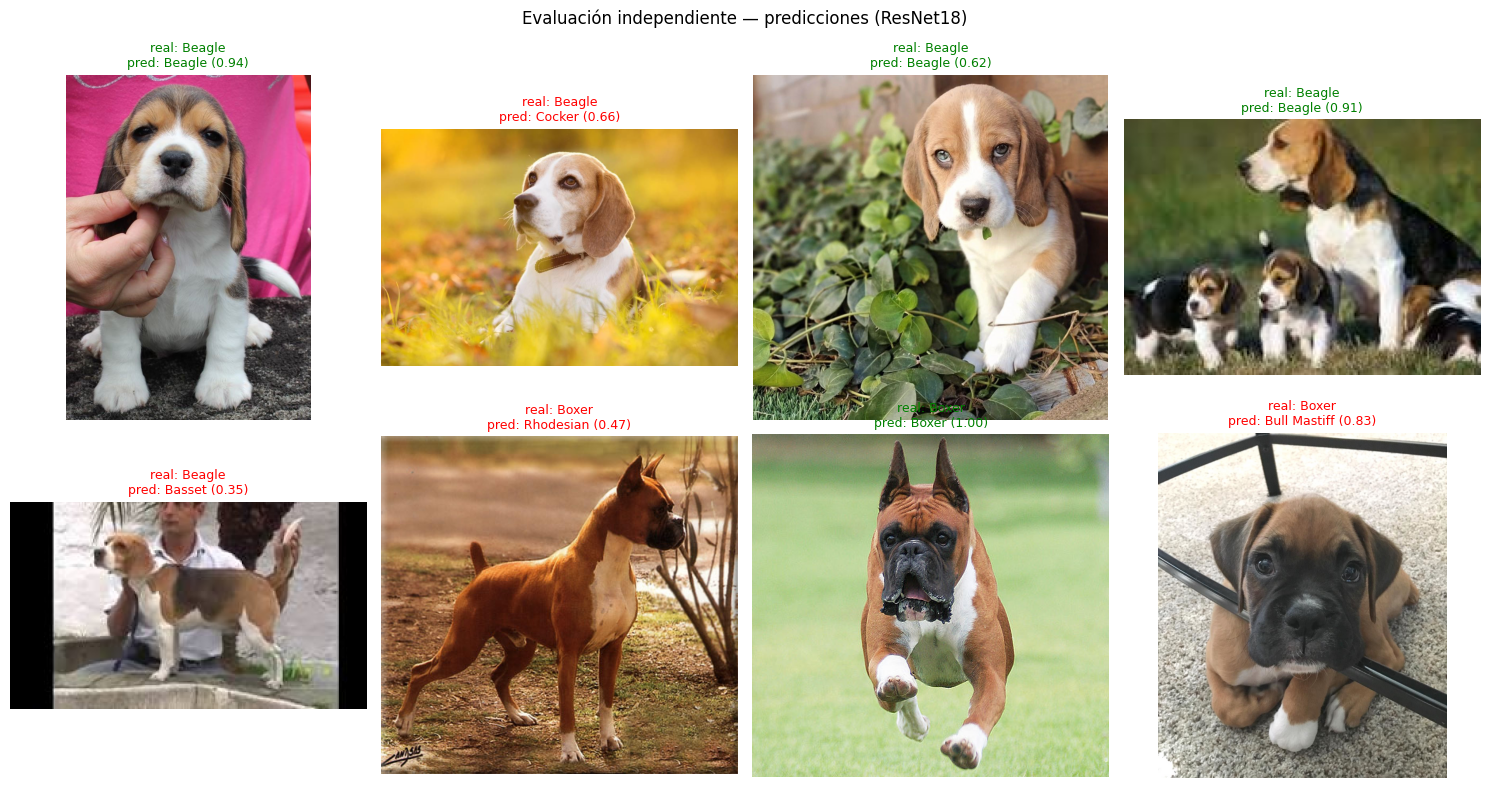

In [ ]:
import cv2, matplotlib.pyplot as plt
from pathlib import Path

# Galería de predicciones (con la ResNet, el mejor modelo)
classifier.set_active_model("resnet18_finetuned")
imgs = [p for bd in sorted(EVAL_DIR.iterdir()) if bd.is_dir()
        for p in bd.iterdir() if p.suffix.lower() in IMG_EXT][:8]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, p in zip(axes.ravel(), imgs):
    img = cv2.imread(str(p))
    pred, conf = predict_breed(img)
    real = p.parent.name
    ok = (pred == real)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.axis("off")
    ax.set_title(f"real: {real}\npred: {pred} ({conf:.2f})",
                 color="green" if ok else "red", fontsize=9)
for ax in axes.ravel()[len(imgs):]:
    ax.axis("off")
plt.suptitle("Evaluación independiente — predicciones (ResNet18)")
plt.tight_layout(); plt.show()


## 10. Descargar los checkpoints

Están ubicados en `models/` del entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Se publican en un link de solo lectura publico.

In [ ]:
!ls -lh models/

total 50M
-rw-r--r-- 1 root root 6.2M Jun 20 18:11 cnn_custom.pth
-rw-r--r-- 1 root root  43M Jun 20 17:54 resnet18_finetuned.pth


In [ ]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")

total 50M
-rw-r--r-- 1 root root 6.2M Jun 20 18:11 cnn_custom.pth
-rw-r--r-- 1 root root  43M Jun 20 17:54 resnet18_finetuned.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>